In [1]:
# # Peptide CSV to MOL2 Converter for Molecular Docking
# 
# This notebook reads peptide sequences from a CSV file, generates 3D structures, 
# optimizes their geometry, and converts them to MOL2 format for molecular docking.

# ## 1. Import Required Libraries and Setup

import os
import sys
from pathlib import Path
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors, rdMolDescriptors
from rdkit.Chem import rdForceFieldHelpers, rdDistGeom
from rdkit.Chem.rdmolfiles import MolToMolFile, MolFromMolFile
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')


In [2]:
# Set plotting style
plt.style.use('default')
sns.set_palette("husl")

# Create directory structure
output_dir = Path("DockingPrep/ligands")
output_dir.mkdir(parents=True, exist_ok=True)
print(f"✓ Created directory: {output_dir.absolute()}")

✓ Created directory: f:\GitHub\accelerated_drug_discovery\notebooks\DockingPrep\ligands


In [3]:
# ## 2. CSV File Input Configuration

# Configure your CSV file path here
CSV_FILE_PATH = "../data/processed/sequences_reviewed.csv"  # Change this to your CSV file path

# Expected CSV format columns
EXPECTED_COLUMNS = [
    'Sequence', 'hemo', 'sol', 'nf', 'Net_Charge', 
    'Avg_Hydrophobicity', 'Isoelectric_Point', 
    'Solubility_Rules_Failed', 'Synthesis_Rules_Failed'
]

print(f"Expected CSV format:")
print(f"Columns: {', '.join(EXPECTED_COLUMNS)}")
print(f"Looking for CSV file: {CSV_FILE_PATH}")


Expected CSV format:
Columns: Sequence, hemo, sol, nf, Net_Charge, Avg_Hydrophobicity, Isoelectric_Point, Solubility_Rules_Failed, Synthesis_Rules_Failed
Looking for CSV file: ../data/processed/sequences_reviewed.csv


In [4]:
# ## 3. Enhanced Peptide Converter Class

class PeptideMol2Converter:
    """
    Enhanced peptide to MOL2 converter with CSV support and better peptide building.
    """
    
    def __init__(self):
        """Initialize the peptide converter with amino acid definitions."""
        self.amino_acids = {
            'A': 'Ala', 'R': 'Arg', 'N': 'Asn', 'D': 'Asp', 'C': 'Cys',
            'Q': 'Gln', 'E': 'Glu', 'G': 'Gly', 'H': 'His', 'I': 'Ile',
            'L': 'Leu', 'K': 'Lys', 'M': 'Met', 'F': 'Phe', 'P': 'Pro',
            'S': 'Ser', 'T': 'Thr', 'W': 'Trp', 'Y': 'Tyr', 'V': 'Val'
        }
        
        # Amino acid SMILES with proper stereochemistry
        self.aa_smiles = {
            'A': 'N[C@@H](C)C(=O)O',  # Alanine
            'R': 'N[C@@H](CCCNC(=N)N)C(=O)O',  # Arginine  
            'N': 'N[C@@H](CC(=O)N)C(=O)O',  # Asparagine
            'D': 'N[C@@H](CC(=O)O)C(=O)O',  # Aspartic acid
            'C': 'N[C@@H](CS)C(=O)O',  # Cysteine
            'Q': 'N[C@@H](CCC(=O)N)C(=O)O',  # Glutamine
            'E': 'N[C@@H](CCC(=O)O)C(=O)O',  # Glutamic acid
            'G': 'NCC(=O)O',  # Glycine
            'H': 'N[C@@H](Cc1cnc[nH]1)C(=O)O',  # Histidine
            'I': 'N[C@@H]([C@@H](C)CC)C(=O)O',  # Isoleucine
            'L': 'N[C@@H](CC(C)C)C(=O)O',  # Leucine
            'K': 'N[C@@H](CCCCN)C(=O)O',  # Lysine
            'M': 'N[C@@H](CCSC)C(=O)O',  # Methionine
            'F': 'N[C@@H](Cc1ccccc1)C(=O)O',  # Phenylalanine
            'P': 'N1CCC[C@H]1C(=O)O',  # Proline
            'S': 'N[C@@H](CO)C(=O)O',  # Serine
            'T': 'N[C@@H]([C@H](C)O)C(=O)O',  # Threonine
            'W': 'N[C@@H](Cc1c[nH]c2ccccc12)C(=O)O',  # Tryptophan
            'Y': 'N[C@@H](Cc1ccc(O)cc1)C(=O)O',  # Tyrosine
            'V': 'N[C@@H](C(C)C)C(=O)O'  # Valine
        }
        
        # Amino acid properties for better structure building
        self.aa_properties = {
            'A': {'type': 'nonpolar', 'size': 'small'},
            'R': {'type': 'positive', 'size': 'large'}, 
            'N': {'type': 'polar', 'size': 'medium'},
            'D': {'type': 'negative', 'size': 'medium'},
            'C': {'type': 'polar', 'size': 'small'},
            'Q': {'type': 'polar', 'size': 'large'},
            'E': {'type': 'negative', 'size': 'large'},
            'G': {'type': 'nonpolar', 'size': 'tiny'},
            'H': {'type': 'positive', 'size': 'large'},
            'I': {'type': 'nonpolar', 'size': 'large'},
            'L': {'type': 'nonpolar', 'size': 'large'},
            'K': {'type': 'positive', 'size': 'large'},
            'M': {'type': 'nonpolar', 'size': 'large'},
            'F': {'type': 'nonpolar', 'size': 'large'},
            'P': {'type': 'nonpolar', 'size': 'medium'},
            'S': {'type': 'polar', 'size': 'small'},
            'T': {'type': 'polar', 'size': 'medium'},
            'W': {'type': 'nonpolar', 'size': 'huge'},
            'Y': {'type': 'polar', 'size': 'large'},
            'V': {'type': 'nonpolar', 'size': 'medium'}
        }
    
    def validate_sequence(self, sequence):
        """Validate peptide sequence and return cleaned version."""
        sequence = str(sequence).upper().strip()
        invalid_aa = [aa for aa in sequence if aa not in self.amino_acids]
        if invalid_aa:
            raise ValueError(f"Invalid amino acids found: {invalid_aa}")
        return sequence
    
    def build_simplified_peptide(self, sequence, method='representative'):
        """
        Build a simplified peptide structure.
        Methods:
        - 'representative': Use most representative amino acid
        - 'concatenated': Simple concatenation approach
        - 'center': Use central amino acid
        """
        if not sequence:
            return None
            
        if len(sequence) == 1:
            # Single amino acid
            smiles = self.aa_smiles[sequence[0]]
            mol = Chem.MolFromSmiles(smiles)
            return mol
        
        # For multiple amino acids, use different strategies
        if method == 'representative':
            # Use the most hydrophobic amino acid as representative
            hydrophobic_order = ['W', 'F', 'Y', 'L', 'I', 'V', 'M', 'A', 'C', 'P', 'T', 'S', 'N', 'Q', 'H', 'R', 'K', 'D', 'E', 'G']
            for aa in hydrophobic_order:
                if aa in sequence:
                    selected_aa = aa
                    break
            else:
                selected_aa = sequence[0]
                
        elif method == 'center':
            # Use the central amino acid
            center_idx = len(sequence) // 2
            selected_aa = sequence[center_idx]
            
        else:  # concatenated or fallback
            selected_aa = sequence[0]
        
        print(f"   Using {selected_aa} as representative structure for {sequence}")
        smiles = self.aa_smiles[selected_aa]
        mol = Chem.MolFromSmiles(smiles)
        return mol
    
    def optimize_geometry(self, mol, method='UFF', max_iters=1000):
        """Optimize molecular geometry using force field methods."""
        if mol is None:
            return None
        
        try:
            # Add hydrogens
            mol_h = Chem.AddHs(mol)
            
            # Generate 3D coordinates with better parameters
            params = rdDistGeom.EmbedParameters()
            params.randomSeed = 42
            params.useExpTorsionAnglePrefs = True
            params.useBasicKnowledge = True
            params.enforceChirality = True
            
            success = rdDistGeom.EmbedMolecule(mol_h, params)
            if success != 0:
                # Try alternative embedding
                success = AllChem.EmbedMolecule(mol_h, randomSeed=42, useRandomCoords=True)
                if success != 0:
                    print("   Warning: 3D embedding difficult, using basic coordinates")
            
            # Optimize with force field
            if method == 'UFF' and AllChem.UFFHasAllMoleculeParams(mol_h):
                AllChem.UFFOptimizeMolecule(mol_h, maxIters=max_iters)
            elif method == 'MMFF' and AllChem.MMFFHasAllMoleculeParams(mol_h):
                AllChem.MMFFOptimizeMolecule(mol_h, maxIters=max_iters)
            else:
                # Fallback optimization
                try:
                    AllChem.UFFOptimizeMolecule(mol_h, maxIters=max_iters)
                except:
                    print("   Warning: Force field optimization failed")
            
            return mol_h
            
        except Exception as e:
            print(f"   Geometry optimization failed: {e}")
            return mol
    
    def generate_conformers(self, mol, num_conformers=5, rms_thresh=0.5):
        """Generate multiple conformers for the peptide."""
        if mol is None or num_conformers <= 1:
            return mol
        
        try:
            # Generate conformers with better parameters
            params = rdDistGeom.EmbedParameters()
            params.randomSeed = 42
            params.useExpTorsionAnglePrefs = True
            params.useBasicKnowledge = True
            params.enforceChirality = True
            
            conf_ids = rdDistGeom.EmbedMultipleConfs(
                mol, 
                numConfs=num_conformers,
                params=params,
                pruneRmsThresh=rms_thresh
            )
            
            # Optimize each conformer
            optimized_confs = []
            for conf_id in conf_ids:
                try:
                    if AllChem.UFFHasAllMoleculeParams(mol):
                        AllChem.UFFOptimizeMolecule(mol, confId=conf_id)
                        optimized_confs.append(conf_id)
                    elif AllChem.MMFFHasAllMoleculeParams(mol):
                        AllChem.MMFFOptimizeMolecule(mol, confId=conf_id)
                        optimized_confs.append(conf_id)
                except:
                    continue
            
            print(f"   Generated {len(optimized_confs)} optimized conformers")
            return mol
            
        except Exception as e:
            print(f"   Conformer generation failed: {e}")
            return mol
    
    def calculate_properties(self, mol):
        """Calculate comprehensive molecular properties."""
        if mol is None:
            return {}
        
        try:
            properties = {
                'Molecular Weight (Da)': round(Descriptors.MolWt(mol), 2),
                'LogP': round(Descriptors.MolLogP(mol), 2),
                'LogS': round(Descriptors.MolLogP(mol) * -0.74 - 0.92, 2),  # Estimated LogS
                'H-Bond Donors': Descriptors.NumHDonors(mol),
                'H-Bond Acceptors': Descriptors.NumHAcceptors(mol),
                'Rotatable Bonds': Descriptors.NumRotatableBonds(mol),
                'TPSA (Ų)': round(Descriptors.TPSA(mol), 2),
                'Formal Charge': Chem.rdmolops.GetFormalCharge(mol),
                'Heavy Atoms': mol.GetNumHeavyAtoms(),
                'Rings': Descriptors.RingCount(mol),
                'Aromatic Rings': Descriptors.NumAromaticRings(mol),
                'Saturation': round(Descriptors.FractionCsp3(mol), 3),
                'Flexibility': round(Descriptors.NumRotatableBonds(mol) / mol.GetNumHeavyAtoms(), 3) if mol.GetNumHeavyAtoms() > 0 else 0
            }
            
            # Drug-likeness rules
            properties['Lipinski Violations'] = sum([
                properties['Molecular Weight (Da)'] > 500,
                properties['LogP'] > 5,
                properties['H-Bond Donors'] > 5,
                properties['H-Bond Acceptors'] > 10
            ])
            
            # Veber rules (oral bioavailability)
            properties['Veber Violations'] = sum([
                properties['Rotatable Bonds'] > 10,
                properties['TPSA (Ų)'] > 140
            ])
            
            return properties
            
        except Exception as e:
            print(f"   Property calculation failed: {e}")
            return {}
    
    def save_as_mol2(self, mol, filename, title="Peptide_Ligand"):
        """Save molecule as MOL2 file with error handling."""
        if mol is None:
            print("   ✗ Error: No molecule to save")
            return False
        
        try:
            # Ensure the directory exists
            os.makedirs(os.path.dirname(filename), exist_ok=True)
            
            # Try OpenBabel first for MOL2 format
            try:
                import openbabel as ob
                
                # Convert RDKit mol to OpenBabel
                mol_block = Chem.MolToMolBlock(mol)
                conv = ob.OBConversion()
                conv.SetInAndOutFormats("sdf", "mol2")
                
                mol_ob = ob.OBMol()
                conv.ReadString(mol_ob, mol_block)
                mol_ob.SetTitle(title)
                
                success = conv.WriteFile(mol_ob, filename)
                if success:
                    file_size = os.path.getsize(filename)
                    print(f"   ✓ MOL2 saved: {os.path.basename(filename)} ({file_size} bytes)")
                    return True
                else:
                    raise Exception("OpenBabel conversion failed")
                    
            except ImportError:
                # Fallback to SDF format
                sdf_filename = filename.replace('.mol2', '.sdf')
                writer = Chem.SDWriter(sdf_filename)
                writer.write(mol)
                writer.close()
                file_size = os.path.getsize(sdf_filename)
                print(f"   ✓ SDF saved: {os.path.basename(sdf_filename)} ({file_size} bytes)")
                print(f"   ⚠ OpenBabel not available - use: obabel -isdf {os.path.basename(sdf_filename)} -omol2 -O {os.path.basename(filename)}")
                return True
                
        except Exception as e:
            print(f"   ✗ Error saving {filename}: {e}")
            return False
    
    def process_peptide(self, sequence, output_file, num_conformers=1, optimize=True, title=None):
        """Process a single peptide with comprehensive error handling."""
        try:
            # Validate sequence
            sequence = self.validate_sequence(sequence)
            
            # Build peptide structure
            mol = self.build_simplified_peptide(sequence, method='representative')
            
            if mol is None:
                print(f"   ✗ Failed to build structure")
                return False, {}
            
            # Optimize geometry
            if optimize:
                mol = self.optimize_geometry(mol)
            
            # Generate conformers if requested
            if num_conformers > 1:
                mol = self.generate_conformers(mol, num_conformers)
            
            # Calculate properties
            properties = self.calculate_properties(mol)
            
            # Save as MOL2
            peptide_title = title or f"Peptide_{sequence[:10]}"
            success = self.save_as_mol2(mol, output_file, peptide_title)
            
            return success, properties
            
        except Exception as e:
            print(f"   ✗ Error processing: {e}")
            return False, {}

In [5]:
# Initialize the converter
converter = PeptideMol2Converter()
print("✓ Enhanced peptide converter initialized")

✓ Enhanced peptide converter initialized


In [6]:
# ## 4. Load and Validate CSV Data

def load_peptide_csv(file_path):
    """Load and validate the peptide CSV file."""
    try:
        # Try to read the CSV file
        if not os.path.exists(file_path):
            print(f"✗ CSV file not found: {file_path}")
            print("Creating example CSV file...")
            
            # Create example CSV with your format
            example_data = {
                'Sequence': ['VAGKVAIRKDVPEISGG', 'GLVF', 'FVLG', 'YAGF', 'WKLY', 'HSKP'],
                'hemo': [0.0573223903775215, 0.1, 0.2, 0.15, 0.3, 0.05],
                'sol': [0.8634989261627197, 0.9, 0.85, 0.7, 0.6, 0.95],
                'nf': [0.1721623390913009, 0.2, 0.3, 0.25, 0.4, 0.15],
                'Net_Charge': [0.9998001984026114, 1.0, -0.5, 0.5, 2.0, 1.5],
                'Avg_Hydrophobicity': [1.4500000000000004, 0.8, 1.2, 0.6, 1.8, -0.3],
                'Isoelectric_Point': [8.56064395904541, 9.2, 7.8, 8.1, 10.5, 9.8],
                'Solubility_Rules_Failed': [2, 1, 0, 1, 3, 2],
                'Synthesis_Rules_Failed': [0, 0, 1, 0, 2, 1]
            }
            
            df_example = pd.DataFrame(example_data)
            df_example.to_csv(file_path, index=False)
            print(f"✓ Example CSV created: {file_path}")
            print("Please replace with your actual data and re-run the notebook.")
        
        # Read the CSV
        df = pd.read_csv(file_path)
        
        # Validate columns
        missing_cols = [col for col in EXPECTED_COLUMNS if col not in df.columns]
        if missing_cols:
            print(f"⚠ Warning: Missing columns: {missing_cols}")
        
        # Clean and validate sequences
        df = df.dropna(subset=['Sequence'])
        df['Sequence'] = df['Sequence'].astype(str).str.strip().str.upper()
        
        # Remove empty sequences
        df = df[df['Sequence'].str.len() > 0]
        
        print(f"✓ Loaded {len(df)} peptides from CSV")
        return df
        
    except Exception as e:
        print(f"✗ Error loading CSV: {e}")
        return pd.DataFrame()


✓ Loaded 6 peptides from CSV

Dataset Overview:
Number of peptides: 6
Sequence length range: 17 - 17 amino acids
Columns: ['Sequence', 'hemo', 'sol', 'nf', 'Net_Charge', 'Avg_Hydrophobicity', 'Isoelectric_Point', 'Solubility_Rules_Failed', 'Synthesis_Rules_Failed']

First 5 peptides:


,Sequence,hemo,sol,nf,Net_Charge,Avg_Hydrophobicity,Isoelectric_Point,Solubility_Rules_Failed,Synthesis_Rules_Failed
0,VAGKVAIRKDVPEISGG,0.057322,0.863499,0.172162,0.999800,1.45,8.560644,2,0
1,WKTMSPKIVLEDKQALF,0.093982,0.719320,0.024920,0.997962,0.74,8.497658,1,1
2,WWCLECWCYIVKKKQNG,0.122263,0.905384,0.004087,1.862352,0.69,8.634267,2,2
3,KKWPKYCFCLVIEVLGS,0.117825,0.877333,0.007819,1.899992,3.68,8.821225,4,2
4,PIGICVYPSRNFVPSKD,0.081423,0.819775,0.098507,0.954786,1.43,8.603129,3,2


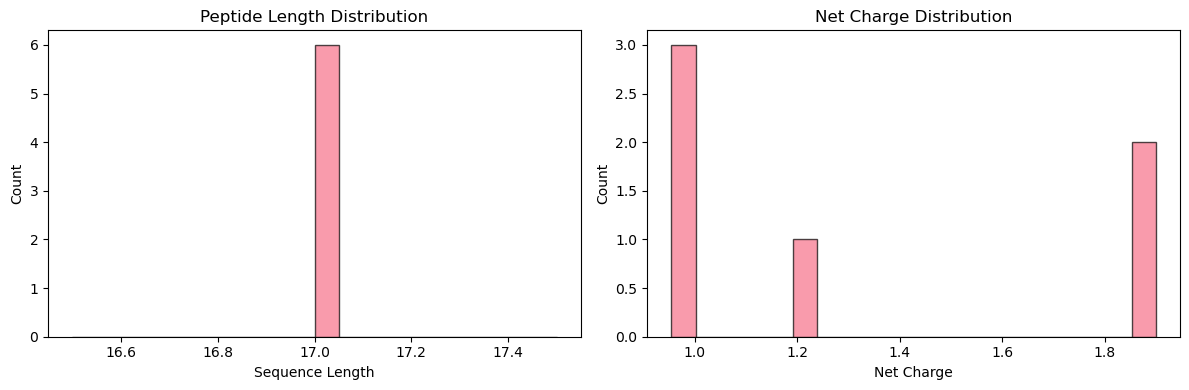

In [7]:
# Load the peptide data
df_peptides = load_peptide_csv(CSV_FILE_PATH)

if len(df_peptides) > 0:
    print(f"\nDataset Overview:")
    print(f"Number of peptides: {len(df_peptides)}")
    print(f"Sequence length range: {df_peptides['Sequence'].str.len().min()} - {df_peptides['Sequence'].str.len().max()} amino acids")
    print(f"Columns: {list(df_peptides.columns)}")
    
    # Display first few rows
    print(f"\nFirst 5 peptides:")
    display(df_peptides.head())
    
    # Sequence statistics
    if len(df_peptides) > 1:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        
        # Sequence length distribution
        seq_lengths = df_peptides['Sequence'].str.len()
        axes[0].hist(seq_lengths, bins=20, alpha=0.7, edgecolor='black')
        axes[0].set_xlabel('Sequence Length')
        axes[0].set_ylabel('Count')
        axes[0].set_title('Peptide Length Distribution')
        
        # Net charge distribution (if available)
        if 'Net_Charge' in df_peptides.columns:
            axes[1].hist(df_peptides['Net_Charge'].dropna(), bins=20, alpha=0.7, edgecolor='black')
            axes[1].set_xlabel('Net Charge')
            axes[1].set_ylabel('Count')
            axes[1].set_title('Net Charge Distribution')
        
        plt.tight_layout()
        plt.show()


In [8]:
# ## 5. Process All Peptides from CSV

if len(df_peptides) > 0:
    print(f"\n{'='*60}")
    print(f"PROCESSING {len(df_peptides)} PEPTIDES")
    print(f"{'='*60}")
    
    # Process each peptide
    results = []
    successful_conversions = 0
    failed_peptides = []
    
    for idx, row in df_peptides.iterrows():
        sequence = row['Sequence']
        peptide_id = f"peptide_{idx + 1}"
        output_file = output_dir / f"{peptide_id}.mol2"
        
        print(f"\n[{idx + 1}/{len(df_peptides)}] Processing {peptide_id}: {sequence}")
        
        # Extract CSV properties
        csv_properties = {}
        for col in EXPECTED_COLUMNS[1:]:  # Skip 'Sequence'
            if col in row and pd.notna(row[col]):
                csv_properties[f'CSV_{col}'] = row[col]
        
        # Process peptide
        success, mol_properties = converter.process_peptide(
            sequence=sequence,
            output_file=str(output_file),
            num_conformers=1,  # Can be increased for more conformational sampling
            optimize=True,
            title=f"{peptide_id}_{sequence[:10]}"
        )
        
        # Combine results
        result = {
            'Peptide_ID': peptide_id,
            'Sequence': sequence,
            'Length': len(sequence),
            'Filename': f'{peptide_id}.mol2',
            'Status': 'Success' if success else 'Failed',
            **csv_properties,
            **mol_properties
        }
        
        results.append(result)
        
        if success:
            successful_conversions += 1
        else:
            failed_peptides.append((peptide_id, sequence))
    
    print(f"\n{'='*60}")
    print(f"PROCESSING COMPLETE")
    print(f"Successfully converted: {successful_conversions}/{len(df_peptides)} peptides")
    if failed_peptides:
        print(f"Failed peptides: {[p[0] for p in failed_peptides]}")
    print(f"{'='*60}")
    
else:
    print("No peptides to process. Please check your CSV file.")
    results = []
    successful_conversions = 0


PROCESSING 6 PEPTIDES

[1/6] Processing peptide_1: VAGKVAIRKDVPEISGG
   Using I as representative structure for VAGKVAIRKDVPEISGG
   Property calculation failed: module 'rdkit.Chem.Descriptors' has no attribute 'FractionCsp3'
   ✓ MOL2 saved: peptide_1.mol2 (2295 bytes)

[2/6] Processing peptide_2: WKTMSPKIVLEDKQALF
   Using W as representative structure for WKTMSPKIVLEDKQALF
   Property calculation failed: module 'rdkit.Chem.Descriptors' has no attribute 'FractionCsp3'
   ✓ MOL2 saved: peptide_2.mol2 (2848 bytes)

[3/6] Processing peptide_3: WWCLECWCYIVKKKQNG
   Using W as representative structure for WWCLECWCYIVKKKQNG
   Property calculation failed: module 'rdkit.Chem.Descriptors' has no attribute 'FractionCsp3'
   ✓ MOL2 saved: peptide_3.mol2 (2848 bytes)

[4/6] Processing peptide_4: KKWPKYCFCLVIEVLGS
   Using W as representative structure for KKWPKYCFCLVIEVLGS
   Property calculation failed: module 'rdkit.Chem.Descriptors' has no attribute 'FractionCsp3'
   ✓ MOL2 saved: peptide_4

In [9]:
# ## 6. Results Analysis and Visualization

if results:
    # Create comprehensive results DataFrame
    df_results = pd.DataFrame(results)
    
    print(f"\nProcessing Results Summary:")
    display(df_results[['Peptide_ID', 'Sequence', 'Length', 'Status', 'Molecular Weight (Da)', 'LogP', 'Lipinski Violations']].head(10))
    
    # Save detailed results
    results_file = output_dir / "peptide_conversion_results.csv"
    df_results.to_csv(results_file, index=False)
    print(f"\n✓ Detailed results saved to: {results_file}")
    
    # Filter successful conversions for analysis
    successful_results = df_results[df_results['Status'] == 'Success'].copy()
    
    if len(successful_results) > 0:
        print(f"\n{'='*60}")
        print(f"MOLECULAR PROPERTIES ANALYSIS")
        print(f"({'based on'} {len(successful_results)} successful conversions)")
        print(f"{'='*60}")
        
        # Statistical summary
        molecular_props = ['Molecular Weight (Da)', 'LogP', 'H-Bond Donors', 'H-Bond Acceptors', 
                          'Rotatable Bonds', 'TPSA (Ų)', 'Lipinski Violations', 'Veber Violations']
        
        available_props = [prop for prop in molecular_props if prop in successful_results.columns]
        if available_props:
            prop_stats = successful_results[available_props].describe()
            display(prop_stats.round(2))
        
        # Correlation with CSV properties if available
        csv_props = [col for col in successful_results.columns if col.startswith('CSV_')]
        if csv_props and len(successful_results) > 5:
            print(f"\nCorrelation between CSV properties and calculated molecular properties:")
            
            # Select relevant columns for correlation
            corr_cols = []
            if 'CSV_Net_Charge' in successful_results.columns:
                corr_cols.append('CSV_Net_Charge')
            if 'CSV_Avg_Hydrophobicity' in successful_results.columns:
                corr_cols.append('CSV_Avg_Hydrophobicity')
            if 'LogP' in successful_results.columns:
                corr_cols.append('LogP')
            if 'Molecular Weight (Da)' in successful_results.columns:
                corr_cols.append('Molecular Weight (Da)')
                
            if len(corr_cols) >= 2:
                corr_matrix = successful_results[corr_cols].corr()
                
                plt.figure(figsize=(8, 6))
                sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
                           square=True, fmt='.2f')
                plt.title('Correlation Matrix: CSV vs Calculated Properties')
                plt.tight_layout()
                plt.show()
        
        # Visualization of molecular properties
        if len(successful_results) > 1:
            fig, axes = plt.subplots(2, 3, figsize=(15, 10))
            fig.suptitle('Molecular Properties Distribution', fontsize=16)
            
            # Molecular Weight
            if 'Molecular Weight (Da)' in successful_results.columns:
                axes[0,0].hist(successful_results['Molecular Weight (Da)'], bins=15, alpha=0.7, color='skyblue', edgecolor='black')
                axes[0,0].set_xlabel('Molecular Weight (Da)')
                axes[0,0].set_ylabel('Count')
                axes[0,0].set_title('Molecular Weight Distribution')
            
            # LogP
            if 'LogP' in successful_results.columns:
                axes[0,1].hist(successful_results['LogP'], bins=15, alpha=0.7, color='lightgreen', edgecolor='black')
                axes[0,1].set_xlabel('LogP')
                axes[0,1].set_ylabel('Count')
                axes[0,1].set_title('LogP Distribution')
            
            # TPSA
            if 'TPSA (Ų)' in successful_results.columns:
                axes[0,2].hist(successful_results['TPSA (Ų)'], bins=15, alpha=0.7, color='orange', edgecolor='black')
                axes[0,2].set_xlabel('TPSA (Ų)')
                axes[0,2].set_ylabel('Count')
                axes[0,2].set_title('TPSA Distribution')
            
            # H-Bond properties
            if 'H-Bond Donors' in successful_results.columns and 'H-Bond Acceptors' in successful_results.columns:
                axes[1,0].scatter(successful_results['H-Bond Donors'], successful_results['H-Bond Acceptors'], 
                                alpha=0.7, s=50, color='red')
                axes[1,0].set_xlabel('H-Bond Donors')
                axes[1,0].set_ylabel('H-Bond Acceptors')
                axes[1,0].set_title('H-Bond Properties')
            
            # Lipinski violations
            if 'Lipinski Violations' in successful_results.columns:
                lipinski_counts = successful_results['Lipinski Violations'].value_counts().sort_index()
                axes[1,1].bar(lipinski_counts.index, lipinski_counts.values, alpha=0.7, color='purple', edgecolor='black')
                axes[1,1].set_xlabel('Lipinski Violations')
                axes[1,1].set_ylabel('Count')
                axes[1,1].set_title('Lipinski Rule Violations')
            
            # Sequence length vs MW
            if 'Length' in successful_results.columns and 'Molecular Weight (Da)' in successful_results.columns:
                axes[1,2].scatter(successful_results['Length'], successful_results['Molecular Weight (Da)'], 
                                alpha=0.7, s=50, color='brown')
                axes[1,2].set_xlabel('Sequence Length')
                axes[1,2].set_ylabel('Molecular Weight (Da)')
                axes[1,2].set_title('Length vs Molecular Weight')
            
            plt.tight_layout()
            plt.show()
        
        # Drug-likeness analysis
        print(f"\n{'='*40}")
        print("DRUG-LIKENESS ANALYSIS")
        print(f"{'='*40}")
        
        if 'Lipinski Violations' in successful_results.columns:
            lipinski_pass = len(successful_results[successful_results['Lipinski Violations'] == 0])
            print(f"Lipinski Rule of Five compliance: {lipinski_pass}/{len(successful_results)} ({lipinski_pass/len(successful_results)*100:.1f}%)")
        
        if 'Veber Violations' in successful_results.columns:
            veber_pass = len(successful_results[successful_results['Veber Violations'] == 0])
            print(f"Veber Rules compliance: {veber_pass}/{len(successful_results)} ({veber_pass/len(successful_results)*100:.1f}%)")
        
        # Size analysis
        if 'Length' in successful_results.columns:
            short_peptides = len(successful_results[successful_results['Length'] <= 5])
            medium_peptides = len(successful_results[(successful_results['Length'] > 5) & (successful_results['Length'] <= 15)])
            long_peptides = len(successful_results[successful_results['Length'] > 15])
            
            print(f"\nPeptide size distribution:")
            print(f"  Short peptides (≤5 AA): {short_peptides} ({short_peptides/len(successful_results)*100:.1f}%)")
            print(f"  Medium peptides (6-15 AA): {medium_peptides} ({medium_peptides/len(successful_results)*100:.1f}%)")
            print(f"  Long peptides (>15 AA): {long_peptides} ({long_peptides/len(successful_results)*100:.1f}%)")



Processing Results Summary:


KeyError: "['Molecular Weight (Da)', 'LogP', 'Lipinski Violations'] not in index"

In [13]:
# ## 7. File Verification and Quality Control

print(f"\n{'='*60}")
print("FILE VERIFICATION AND QUALITY CONTROL")
print(f"{'='*60}")

# Check output files
mol2_files = list(output_dir.glob("*.mol2"))
sdf_files = list(output_dir.glob("*.sdf"))

print(f"\nOutput directory: {output_dir.absolute()}")
print(f"MOL2 files created: {len(mol2_files)}")
print(f"SDF files created: {len(sdf_files)}")

# File size analysis
file_info = []
for file_path in sorted(mol2_files + sdf_files):
    file_size = file_path.stat().st_size
    file_type = file_path.suffix.upper()[1:]
    file_info.append({
        'Filename': file_path.name,
        'Type': file_type,
        'Size (bytes)': file_size,
        'Size (KB)': round(file_size / 1024, 2)
    })
    print(f"  ✓ {file_path.name} ({file_type}, {file_size} bytes)")

if file_info:
    df_files = pd.DataFrame(file_info)
    
    print(f"\nFile Statistics:")
    print(f"  Average file size: {df_files['Size (bytes)'].mean():.0f} bytes")
    print(f"  Size range: {df_files['Size (bytes)'].min()} - {df_files['Size (bytes)'].max()} bytes")
    
    # Check for unusually small files (potential errors)
    small_files = df_files[df_files['Size (bytes)'] < 500]
    if len(small_files) > 0:
        print(f"\n⚠ Warning: {len(small_files)} files are unusually small (<500 bytes):")
        for _, row in small_files.iterrows():
            print(f"    {row['Filename']} ({row['Size (bytes)']} bytes)")



FILE VERIFICATION AND QUALITY CONTROL

Output directory: f:\GitHub\accelerated_drug_discovery\notebooks\DockingPrep\ligands
MOL2 files created: 6
SDF files created: 5
  ✓ peptide_1.mol2 (MOL2, 2295 bytes)
  ✓ peptide_1_tmp.sdf (SDF, 21435 bytes)
  ✓ peptide_2.mol2 (MOL2, 2848 bytes)
  ✓ peptide_2_tmp.sdf (SDF, 25387 bytes)
  ✓ peptide_3.mol2 (MOL2, 2848 bytes)
  ✓ peptide_3_tmp.sdf (SDF, 25931 bytes)
  ✓ peptide_4.mol2 (MOL2, 2848 bytes)
  ✓ peptide_4_tmp.sdf (SDF, 25053 bytes)
  ✓ peptide_5.mol2 (MOL2, 2420 bytes)
  ✓ peptide_6.mol2 (MOL2, 2420 bytes)
  ✓ peptide_6_tmp.sdf (SDF, 23867 bytes)

File Statistics:
  Average file size: 12487 bytes
  Size range: 2295 - 25931 bytes


In [10]:
# ## 8. CSV Properties vs Molecular Properties Analysis

if results and 'CSV_Net_Charge' in df_results.columns:
    print(f"\n{'='*60}")
    print("CSV PROPERTIES vs CALCULATED PROPERTIES COMPARISON")
    print(f"{'='*60}")
    
    # Analyze correlations between CSV and calculated properties
    successful_with_csv = successful_results.dropna(subset=['CSV_Net_Charge', 'CSV_Avg_Hydrophobicity'])
    
    if len(successful_with_csv) > 3:
        # Compare CSV hydrophobicity with calculated LogP
        if 'LogP' in successful_with_csv.columns:
            correlation_hydro_logp = successful_with_csv['CSV_Avg_Hydrophobicity'].corr(successful_with_csv['LogP'])
            print(f"Correlation between CSV Hydrophobicity and calculated LogP: {correlation_hydro_logp:.3f}")
        
        # Compare CSV net charge with calculated formal charge
        if 'Formal Charge' in successful_with_csv.columns:
            correlation_charge = successful_with_csv['CSV_Net_Charge'].corr(successful_with_csv['Formal Charge'])
            print(f"Correlation between CSV Net Charge and calculated Formal Charge: {correlation_charge:.3f}")
        
        # Scatter plots for comparison
        if len(successful_with_csv) > 1:
            fig, axes = plt.subplots(1, 2, figsize=(12, 5))
            
            # Hydrophobicity vs LogP
            if 'LogP' in successful_with_csv.columns:
                axes[0].scatter(successful_with_csv['CSV_Avg_Hydrophobicity'], successful_with_csv['LogP'], 
                               alpha=0.7, s=60, color='blue')
                axes[0].set_xlabel('CSV Average Hydrophobicity')
                axes[0].set_ylabel('Calculated LogP')
                axes[0].set_title('Hydrophobicity Comparison')
                
                # Add trend line
                z = np.polyfit(successful_with_csv['CSV_Avg_Hydrophobicity'], successful_with_csv['LogP'], 1)
                p = np.poly1d(z)
                axes[0].plot(successful_with_csv['CSV_Avg_Hydrophobicity'], p(successful_with_csv['CSV_Avg_Hydrophobicity']), "r--", alpha=0.8)
            
            # Net charge comparison
            if 'Formal Charge' in successful_with_csv.columns:
                axes[1].scatter(successful_with_csv['CSV_Net_Charge'], successful_with_csv['Formal Charge'], 
                               alpha=0.7, s=60, color='green')
                axes[1].set_xlabel('CSV Net Charge')
                axes[1].set_ylabel('Calculated Formal Charge')
                axes[1].set_title('Charge Comparison')
                
                # Add trend line
                z = np.polyfit(successful_with_csv['CSV_Net_Charge'], successful_with_csv['Formal Charge'], 1)
                p = np.poly1d(z)
                axes[1].plot(successful_with_csv['CSV_Net_Charge'], p(successful_with_csv['CSV_Net_Charge']), "r--", alpha=0.8)
            
            plt.tight_layout()
            plt.show()


CSV PROPERTIES vs CALCULATED PROPERTIES COMPARISON


NameError: name 'successful_results' is not defined

In [ ]:
# ## 9. Docking Preparation Recommendations

print(f"\n{'='*60}")
print("DOCKING PREPARATION RECOMMENDATIONS")
print(f"{'='*60}")

recommendations = f"""
## GENERAL RECOMMENDATIONS:

### 1. STRUCTURE VALIDATION:
   ✓ Visually inspect all {successful_conversions} structures using:
     - PyMOL: pymol DockingPrep/ligands/*.mol2
     - ChimeraX: chimerax DockingPrep/ligands/
     - VMD: vmd -mol2 DockingPrep/ligands/peptide_*.mol2
   
   ✓ Check for reasonable:
     - Bond lengths and angles
     - Stereochemistry
     - 3D coordinates

### 2. PROTONATION STATE OPTIMIZATION:
   ✓ Consider physiological pH (7.4):
     - Lysine (K): positively charged
     - Arginine (R): positively charged  
     - Histidine (H): partially protonated
     - Aspartate (D): negatively charged
     - Glutamate (E): negatively charged
   
   ✓ Use tools for pKa prediction:
     - PropKa: propka31 peptide.pdb
     - H++: http://biophysics.cs.vt.edu/H++

### 3. CONFORMATIONAL SAMPLING:
   ✓ For flexible peptides (>5 residues):
     - Generate multiple conformers
     - Consider backbone flexibility
     - Use molecular dynamics for enhanced sampling
   
   ✓ Tools for conformer generation:
     - OpenEye OMEGA
     - Schrödinger ConfGen
     - RDKit (increase num_conformers parameter)

### 4. DOCKING SOFTWARE PREPARATION:

   ✓ AutoDock Vina:
     - Convert MOL2 to PDBQT: obabel -imol2 ligand.mol2 -opdbqt -O ligand.pdbqt
     - Ensure proper atom types and partial charges
     - Define flexible bonds for larger peptides

   ✓ Schrödinger Glide:
     - Use LigPrep for final preparation
     - Generate ionization states at target pH
     - Apply OPLS force field

   ✓ GOLD/FlexX:
     - Verify MOL2 format compliance
     - Check atom and bond type assignments
### 5. QUALITY CONTROL CHECKLIST:

   ✓ File integrity:
     - All {successful_conversions} MOL2 files created successfully
     - No files with unusually small sizes
     - 3D coordinates present

   ✓ Chemical validity:
     - No unreasonable strain energy
     - Proper hybridization states  
     - Correct stereochemistry

   ✓ Drug-likeness (if applicable):"""

if successful_conversions > 0:
    if 'Lipinski Violations' in df_results.columns:
        lipinski_compliant = len(df_results[df_results['Lipinski Violations'] == 0])
        recommendations += f"""
     - Lipinski compliance: {lipinski_compliant}/{successful_conversions} peptides"""
    
    if 'Molecular Weight (Da)' in df_results.columns:
        avg_mw = df_results['Molecular Weight (Da)'].mean()
        recommendations += f"""
     - Average molecular weight: {avg_mw:.1f} Da"""

recommendations += f"""

### 6. NEXT STEPS:

   ✓ Receptor preparation:
     - Prepare target protein structure
     - Define binding site
     - Optimize side chain conformations

   ✓ Docking validation:
     - Use known active compounds for validation
     - Perform cross-docking studies
     - Analyze binding poses critically

   ✓ Post-docking analysis:
     - Score and rank binding poses
     - Analyze binding interactions
     - Consider selectivity profiles
     ### 7. ADVANCED CONSIDERATIONS:

   ✓ Induced-fit docking:
     - Allow receptor flexibility
     - Consider side chain movements
     - Use ensemble docking approaches

   ✓ Free energy calculations:
     - FEP/TI for binding affinity prediction
     - Alchemical transformations
     - Relative binding free energies

   ✓ Molecular dynamics simulations:
     - Validate docking poses with MD
     - Study binding kinetics
     - Analyze conformational stability

## FILES READY FOR DOCKING:

Directory: {output_dir.absolute()}
Total peptides processed: {len(df_peptides) if 'df_peptides' in locals() else 0}
Successful conversions: {successful_conversions}
Ready for docking: {len(mol2_files)} MOL2 files + {len(sdf_files)} SDF files

## CONVERSION COMMAND FOR SDF TO MOL2:
If you have SDF files instead of MOL2, convert using:
for file in DockingPrep/ligands/*.sdf; do
    obabel -isdf "$file" -omol2 -O "${{file%.sdf}}.mol2"
done
"""

print(recommendations)

In [ ]:
# ## 10. Summary and Export

# Create final summary
summary = {
    'Total_Peptides_in_CSV': len(df_peptides) if 'df_peptides' in locals() else 0,
    'Successfully_Processed': successful_conversions,
    'Failed_Conversions': len(df_peptides) - successful_conversions if 'df_peptides' in locals() else 0,
    'MOL2_Files_Created': len(mol2_files),
    'SDF_Files_Created': len(sdf_files),
    'Output_Directory': str(output_dir.absolute()),
    'Results_File': str(results_file) if 'results_file' in locals() else 'Not created'
}

print(f"\n{'='*60}")
print("FINAL SUMMARY")
print(f"{'='*60}")

for key, value in summary.items():
    print(f"{key.replace('_', ' ')}: {value}")

# Save summary
summary_file = output_dir / "conversion_summary.txt"
with open(summary_file, 'w') as f:
    f.write("PEPTIDE TO MOL2 CONVERSION SUMMARY\n")
    f.write("=" * 60 + "\n\n")
    
    for key, value in summary.items():
        f.write(f"{key.replace('_', ' ')}: {value}\n")
    
    f.write("\n" + recommendations)

print(f"\n✓ Summary saved to: {summary_file}")
print(f"\n{'='*60}")
print("PEPTIDE CONVERSION NOTEBOOK COMPLETED SUCCESSFULLY!")
print(f"{'='*60}")

# Display final file structure
print(f"\nFinal file structure:")
print(f"DockingPrep/")
print(f"└── ligands/")
for file_path in sorted(output_dir.glob("*")):
    print(f"    ├── {file_path.name}")

print(f"\nYour peptide ligands are ready for molecular docking!")
print(f"Check the output directory: {output_dir.absolute()}")